# 导入数据

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./jd1.csv')
df = df.drop_duplicates()
df.head()

,用户名,评分,评论时间,评论内容
0,T***M,5,2026-01-23 00:14:49,配料表里没有猪肉，纯虾肉。味道很鲜美，一盒有上下两层馄饨，6袋调味包。我就喜欢这种皮薄的，皮...
1,j***u,5,2026-01-28 09:43:03,正大食品质量好，值得信赖。玉米蔬菜猪肉蒸饺薄皮大馅，汁水丰富。蒸着吃好吃，煎着吃更香。份量很...
2,j***6,5,2026-01-27 19:09:13,一共二十四个，个头不小，馅料也很足，很容易煮熟，差不多开锅就熟，不要久煮饺子皮容易破。做煎饺...
3,雨***虹,5,2026-01-13 07:39:43,正大食品，知名品牌，食品安全有保障。这款虾饺，皮儿薄馅儿大，选用南美白对虾，鲜美可口，煎、炸...
4,jd_156357gta,5,2025-12-30 12:21:31,这韭菜盒子真的是让我惊艳到了！外皮烤得恰到好处，酥脆而不油腻，轻轻一咬，就能感受到那层层的酥...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   用户名     283 non-null    object
 1   评分      283 non-null    int64 
 2   评论时间    283 non-null    object
 3   评论内容    283 non-null    object
dtypes: int64(1), object(3)
memory usage: 9.0+ KB


# 数据处理

In [4]:
df['评论时间'] = pd.to_datetime(df['评论时间'])
df['周几'] = df['评论时间'].dt.weekday
mapping = {
    0:'周一',
    1:'周二',
    2:'周三',
    3:'周四',
    4:'周五',
    5:'周六',
    6:'周日',
}
df['周几'] = df['周几'].map(mapping)

df['小时'] = df['评论时间'].dt.hour
df


,用户名,评分,评论时间,评论内容,周几,小时
0,T***M,5,2026-01-23 00:14:49,配料表里没有猪肉，纯虾肉。味道很鲜美，一盒有上下两层馄饨，6袋调味包。我就喜欢这种皮薄的，皮...,周五,0
1,j***u,5,2026-01-28 09:43:03,正大食品质量好，值得信赖。玉米蔬菜猪肉蒸饺薄皮大馅，汁水丰富。蒸着吃好吃，煎着吃更香。份量很...,周三,9
2,j***6,5,2026-01-27 19:09:13,一共二十四个，个头不小，馅料也很足，很容易煮熟，差不多开锅就熟，不要久煮饺子皮容易破。做煎饺...,周二,19
3,雨***虹,5,2026-01-13 07:39:43,正大食品，知名品牌，食品安全有保障。这款虾饺，皮儿薄馅儿大，选用南美白对虾，鲜美可口，煎、炸...,周二,7
4,jd_156357gta,5,2025-12-30 12:21:31,这韭菜盒子真的是让我惊艳到了！外皮烤得恰到好处，酥脆而不油腻，轻轻一咬，就能感受到那层层的酥...,周二,12
...,...,...,...,...,...,...
278,j***y,5,2026-01-07 22:03:45,好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃好吃...,周三,22
279,恋***l,5,2025-03-03 12:27:33,包装完好物美价廉好好好好,周一,12
280,1***9,5,2025-02-07 10:36:03,OKOKOKOKOKOK哦哦OKOKOK哦哦吗,周五,10
281,_***c,5,2024-06-10 15:04:28,👌🏻挺好的哦噢噢哦哦哦噢噢噢噢哦哦,周一,15


# 情感分析

In [5]:
from snownlp import SnowNLP
import numpy as np
 
def process1(x):
    try:
        score = SnowNLP(x).sentiments
        return score
    except:
        return np.nan
     
df_ = df['评论内容'].drop_duplicates().to_frame().reset_index(drop=True)
 
df_['情感得分'] = df_['评论内容'].apply(process1)

In [6]:
df_['评分等级'] = pd.cut(df_['情感得分'],bins=[0, 0.5, 0.8, 1],labels=['差评', '中评', '好评'],right=False)  # 包含左边界，不包含右边界

# 可视化

In [7]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import seaborn as sns

## 4.1情感得分分布直方图

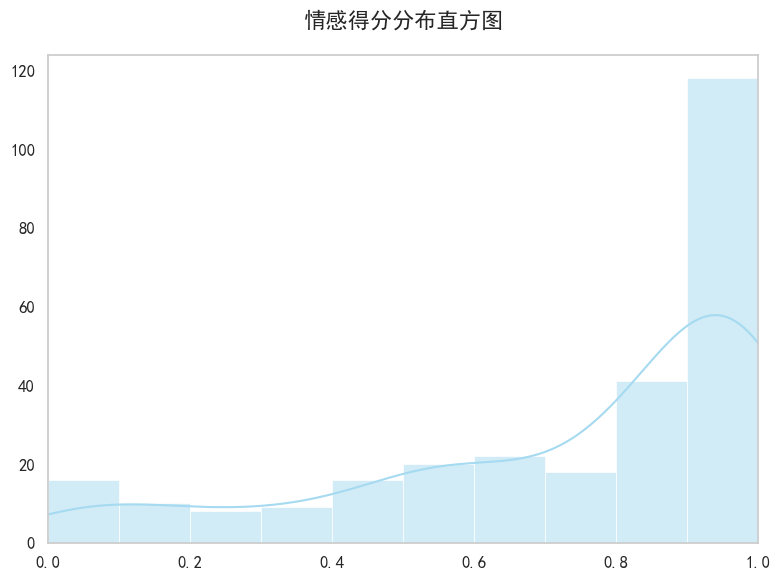

In [9]:
sns.set(style="whitegrid", font_scale=1.1,font='SimHei')

plt.figure(figsize=(8, 6))


ax = sns.histplot(
    data=df_,
    x='情感得分',
    bins=10,  # 可以调整箱数
    kde=True,  # 添加核密度估计曲线
    color='#a5daf0',
    edgecolor='white',
    linewidth=0.5
)

plt.title('情感得分分布直方图', pad=20, fontsize=16)
plt.xlabel('')
plt.ylabel('')

plt.xlim(0, 1)
plt.tight_layout()
plt.grid(False)

plt.savefig('./Visualization/情感得分分布直方图.jpg')
plt.show()

## 4.2评分等级分布情况

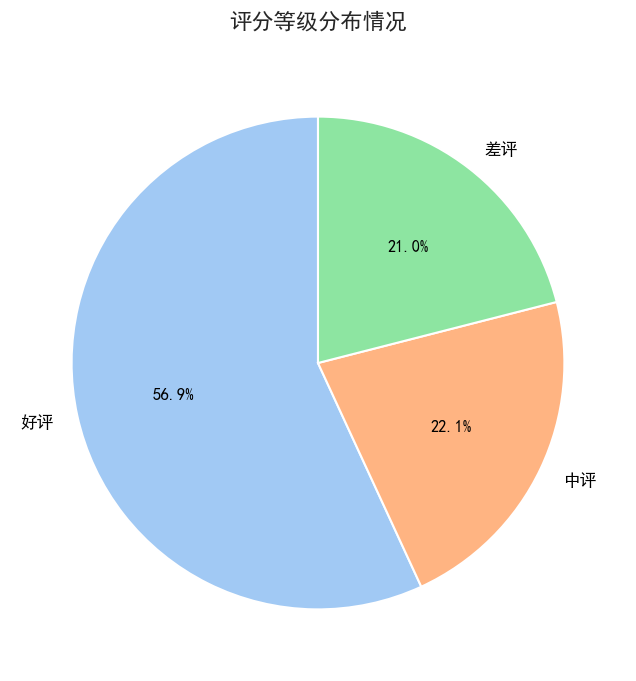

In [10]:
size_counts = df_['评分等级'].value_counts()

plt.figure(figsize=(8, 8))  # 设置画布大小


plt.pie(
    size_counts,  # 数据
    labels=size_counts.index,  # 标签
    autopct='%1.1f%%',  # 显示百分比
    startangle=90,  # 起始角度
    colors=sns.color_palette("pastel"),  # 使用 Seaborn 的 pastel 调色板
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},  # 设置扇形边缘样式
    textprops={'fontsize': 12, 'color': 'black'}  # 设置文本样式
)

plt.title("评分等级分布情况", fontsize=16, fontweight='bold', pad=20)

plt.savefig('./Visualization/评分等级分布情况.jpg')

plt.show()

## 4.3基于星期的用户活跃度变化趋势

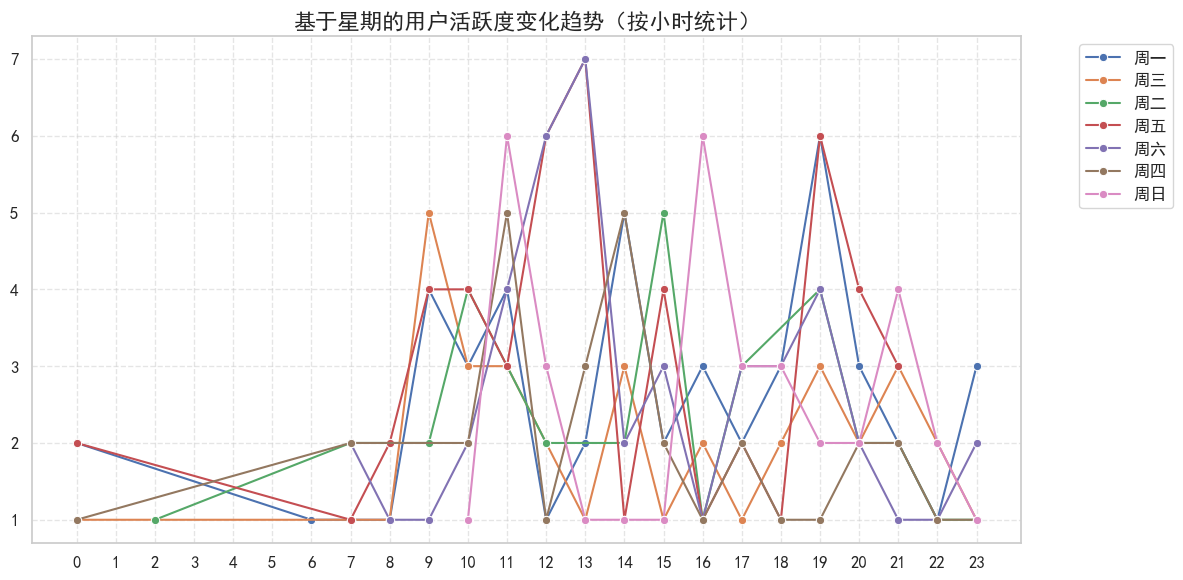

In [11]:
result = df.groupby(["周几", "小时"]).size().reset_index(name="评论数量")
plt.figure(figsize=(12, 6))
sns.lineplot(data=result, x="小时", y="评论数量", hue="周几", marker="o")
plt.title("基于星期的用户活跃度变化趋势（按小时统计）", fontsize=16, fontweight="bold")
plt.xlabel("", fontsize=12)
plt.ylabel("", fontsize=12)
plt.xticks(range(24))  
plt.legend(title="", bbox_to_anchor=(1.05, 1), loc="upper left") #将图例放在右侧
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()  #自动调整布局

plt.savefig('./Visualization/基于星期的用户活跃度变化趋势.jpg')
plt.show()



## 4.4 评论词云

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\26283\AppData\Local\Temp\jieba.cache
Loading model cost 0.369 seconds.
Prefix dict has been built successfully.


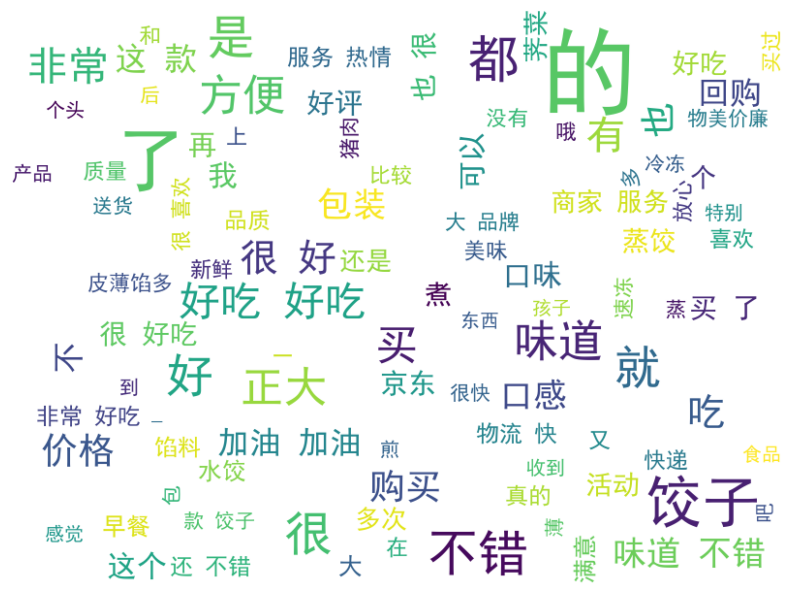

In [12]:
from wordcloud import WordCloud
import jieba


all_text = ' '.join([str(item) for item in df['评论内容'] if isinstance(item, str)])
words = jieba.lcut(all_text)
all_text = ' '.join(words)

wordcloud = WordCloud(
    font_path='simhei.ttf',  # 设置字体路径（支持中文）
    width=800,
    height=600,
    background_color='white',  # 设置背景颜色
    max_words=100,  # 设置最多显示的词数
    min_font_size=10,  # 设置最小字体大小
    max_font_size=100,  # 设置最大字体大小
    random_state=42  # 设置随机种子
).generate(all_text)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title('', fontsize=16)

plt.savefig('./Visualization/评论词云.jpg')
plt.show()